<a href="https://colab.research.google.com/github/PacktPublishing/Modern-Computer-Vision-with-PyTorch-2E/blob/main/Chapter11/neural_style_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install torch_snippets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.5/470.5 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.4 MB/s eta 0:00:00


KeyboardInterrupt: 

In [1]:
from torch_snippets import *
from torchvision import transforms as T
from torch.nn import functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
from torchvision.models import vgg19

preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.Lambda(lambda x: x.mul_(255)),
])
postprocess = T.Compose([
    T.Lambda(lambda x: x.mul_(1.0 / 255)),
    T.Normalize(
        mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
        std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
    ),
])

In [3]:
class GramMatrix(nn.Module):
    def forward(self, input):
        b, c, h, w = input.size()
        feat = input.view(b, c, h * w)
        G = feat @ feat.transpose(1, 2)
        G.div_(h * w)
        return G


class GramMSELoss(nn.Module):
    def forward(self, input, target):
        out = F.mse_loss(GramMatrix()(input), target)
        return out


class vgg19_modified(nn.Module):
    def __init__(self):
        super().__init__()
        features = list(vgg19(pretrained=True).features)
        self.features = nn.ModuleList(features).eval()

    def forward(self, x, layers=[]):
        order = np.argsort(layers)
        _results, results = [], []
        for ix, model in enumerate(self.features):
            x = model(x)
            if ix in layers:
                _results.append(x)
        for o in order:
            results.append(_results[o])
        return results if layers is not [] else x


In [4]:
vgg = vgg19_modified().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 156MB/s]


In [5]:
!wget -q https://huggingface.co/datasets/sizhkhy/mcvp-datasets/resolve/main/60.jpg?download=true -O 60.jpg
!wget -q https://huggingface.co/datasets/sizhkhy/mcvp-datasets/resolve/main/style_image.png?download=true -O style_image.png

In [6]:
imgs = [
    Image.open(path).resize((512, 512)).convert("RGB")
    for path in ["style_image.png", "60.jpg"]
]
style_image, content_image = [preprocess(img).to(device)[None] for img in imgs]

In [7]:
opt_img = content_image.data.clone()
opt_img.requires_grad = True

In [8]:
style_layers = [0, 5, 10, 19, 28]
content_layers = [21]
loss_layers = style_layers + content_layers

In [9]:
loss_fns = [GramMSELoss()] * len(style_layers) + [nn.MSELoss()] * len(content_layers)
loss_fns = [loss_fn.to(device) for loss_fn in loss_fns]

In [10]:
style_weights = [1000 / n**2 for n in [64, 128, 256, 512, 512]]
content_weights = [1]
weights = style_weights + content_weights

In [11]:
style_targets = [GramMatrix()(A).detach() for A in vgg(style_image, style_layers)]
content_targets = [A.detach() for A in vgg(content_image, content_layers)]
targets = style_targets + content_targets

In [12]:
max_iters = 500
optimizer = optim.LBFGS([opt_img])
log = Report(max_iters)

In [13]:
iters = 0
while iters < max_iters:

    def closure():
        global iters
        iters += 1
        optimizer.zero_grad()
        out = vgg(opt_img, loss_layers)
        layer_losses = [
            weights[a] * loss_fns[a](A, targets[a]) for a, A in enumerate(out)
        ]
        loss = sum(layer_losses)
        loss.backward()
        log.record(pos=iters, loss=loss, end="\r")
        return loss

    optimizer.step(closure)

EPOCH: 502.000  loss: 11495540.000  (64.65s - -0.26s remaining)

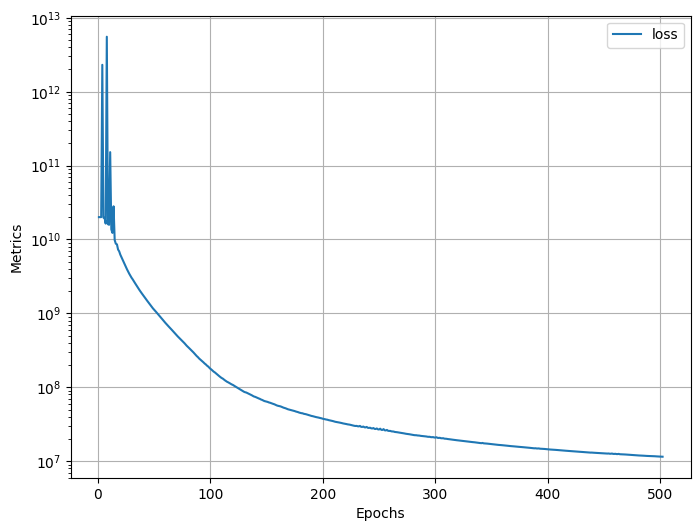

In [14]:
log.plot(log=True)

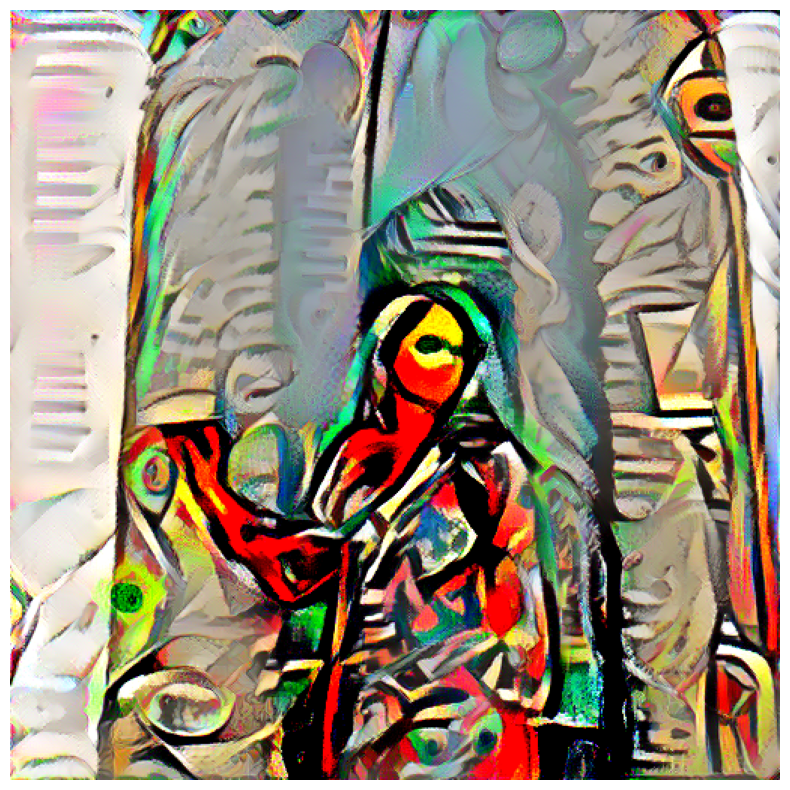

In [15]:
with torch.no_grad():
    out_img = postprocess(opt_img[0]).permute(1, 2, 0)
show(out_img)